# Dynamic Hedge Ratio Estimation using Kalman Filtering

## Objective

Conditional cointegration testing identified **USD–EUR 5Y** as the only spread that is both statistically cointegrated and economically tradable within **Regime 2**.

However, the cointegration step estimates a **static hedge ratio** using OLS.

In practice, cross-country rate relationships drift over time due to:

- Monetary policy divergence
- Structural changes in funding markets
- Changing term premia
- Liquidity shocks

Therefore we estimate a **time-varying hedge ratio** using a **Kalman filter**.

Important point:

> Kalman filtering here is **not used as a forecasting model**.  
> It is used as an **adaptive measurement tool** to track structural drift in the spread relationship.

This follows standard practice in relative value trading where Kalman filtering allows hedge ratios to adjust gradually to structural changes in the underlying relationship.

---

## State Space Representation

We model the relationship as:

$$
y_t = \alpha_t + \beta_t x_t + \varepsilon_t
$$

where:

- $y_t$ = USD 5Y yield
- $x_t$ = EUR 5Y yield
- $\alpha_t$ = time-varying intercept
- $\beta_t$ = time-varying hedge ratio

The state vector follows a random walk:

$$
\begin{bmatrix}
\alpha_t \\
\beta_t
\end{bmatrix}
=
\begin{bmatrix}
\alpha_{t-1} \\
\beta_{t-1}
\end{bmatrix}
+
\eta_t
$$

with

$$
\eta_t \sim N(0, W)
$$

The observation equation is:

$$
y_t = F_t \theta_t + \varepsilon_t
$$

where

$$
F_t = [1, x_t]
$$

and

$$
\theta_t =
\begin{bmatrix}
\alpha_t \\
\beta_t
\end{bmatrix}
$$

The resulting dynamic spread is:

$$
S_t = y_t - \alpha_t - \beta_t x_t
$$

This spread is the object carried forward into the mean-reversion analysis.

In [19]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    start = start.resolve()

    for path in [start] + list(start.parents):
        if (path / "src").exists() and (path / "DATA").exists():
            return path

    raise FileNotFoundError("Could not find repo root containing both 'src' and 'DATA' folders.")

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo root:", ROOT)

Repo root: C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from src.spreads.contracts import get_contract_by_pair_id
from src.spreads.kalman import run_kalman_for_contract

In [22]:
# PAIR_ID = "USD_EUR_5Y"
import pandas as pd
from src.spreads.contracts import get_contract_by_pair_id

# 1. Setup paths and ID
PAIR_ID = "JPY-AUD 5Y"
csv_path = ROOT / "results" / "approved_pairs.csv"

# 2. Load the Contract (for metadata)
contract = get_contract_by_pair_id(pair_id=PAIR_ID, csv_path=csv_path)

# 3. Side-load the Stats (Beta and Intercept) from the CSV
# Since the class is missing these fields, we fetch them manually
df_stats = pd.read_csv(csv_path)
stats = df_stats[df_stats['pair_id'] == PAIR_ID].iloc[0]

# Attach them to the object manually so your code works
contract.hedge_ratio = stats['hedge_ratio']
contract.intercept = stats['intercept']

print("SUCCESS: Contract and Stats loaded!")
print(f"Using pair: {contract.pair_id}")
print(f"Hedge Ratio (Beta): {contract.hedge_ratio:.4f}")
print(f"Intercept (Alpha): {contract.intercept:.4f}")

SUCCESS: Contract and Stats loaded!
Using pair: JPY-AUD 5Y
Hedge Ratio (Beta): 0.2505
Intercept (Alpha): -0.4653


In [31]:
# Edited

spread_df = run_kalman_for_contract(
    yields_df=yields,
    pair_id=contract.pair_id,
    y_col=contract.y_col,
    x_col=contract.x_col,
    out_dir=str(ROOT / "results" / "spreads"),
    
    # delta controls how fast beta moves. 
    # Reducing this makes the hedge ratio more stable.
    delta=1e-6,    # Changed from 1e-4
    
    # obs_var controls how much we "trust" the observation. 
    # Increasing this allows the spread to widen further.
    obs_var=1e-1,  # Changed from 1e-3
)

spread_df.head()

C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526\src\spreads\kalman.py:72: RuntimeWarning: invalid value encountered in divide
  innovation / np.sqrt(innovation_var),


,y,x,alpha_t,beta_t,spread_t,innovation_t,innovation_var_t,innovation_z_t,pair_id
date,,,,,,,,,
1999-11-02,0.887,6.275,0.000000,1.000000,-5.388000,0.000000,0.000000,NaN,JPY-AUD 5Y
1999-12-06,0.979,6.323,-0.130087,0.177462,-0.013009,-5.344000,41.080370,-0.833776,JPY-AUD 5Y
1999-12-07,0.997,6.285,-0.129597,0.178312,0.005907,0.011735,0.198666,0.026328,JPY-AUD 5Y
1999-12-08,0.968,6.298,-0.129964,0.177027,-0.016952,-0.025411,0.149897,-0.065634,JPY-AUD 5Y
1999-12-09,0.948,6.295,-0.130485,0.175665,-0.027323,-0.036421,0.133298,-0.099757,JPY-AUD 5Y


## Interpretation

The Kalman filter produces time-varying estimates of:

- $\alpha_t$
- $\beta_t$

A stable $\beta_t$ suggests that the cross-market relationship is persistent.

A drifting $\beta_t$ suggests that the equilibrium relationship is evolving over time, which motivates the use of a dynamic rather than static spread construction.

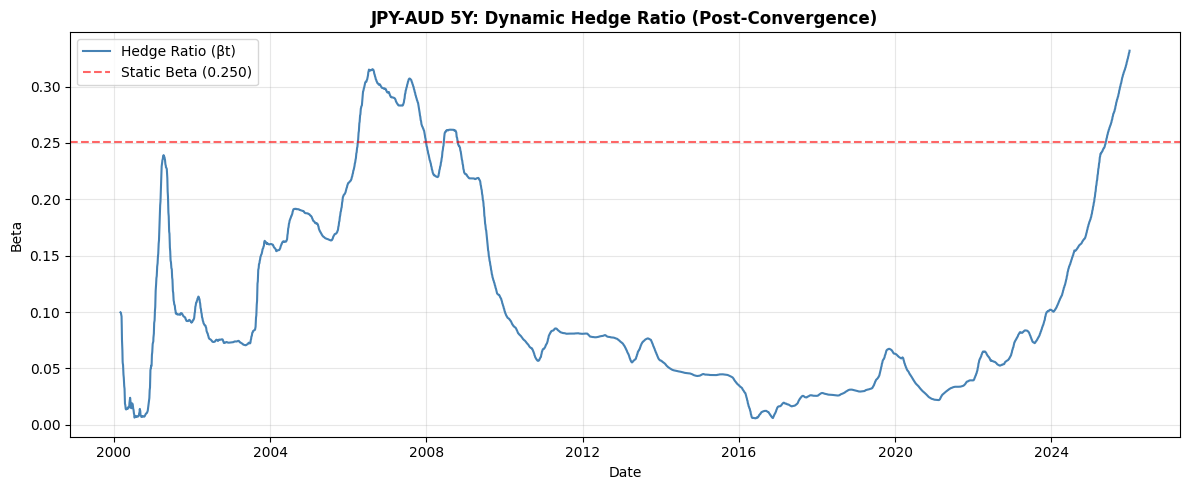

In [32]:
# --- Configuration ---
BURN_IN = 60  # Skip the first 60 days to allow Kalman to converge
# Slice the dataframe to remove the convergence spike
plot_df = spread_df.iloc[BURN_IN:]

"""
plt.figure(figsize=(12, 5))
plt.plot(spread_df.index, spread_df["beta_t"])
# plt.title("USD–EUR 5Y Dynamic Hedge Ratio ($\\beta_t$)")
plt.title("JPY-AUD 5Y Dynamic Hedge Ratio ($\\beta_t$)")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.grid(True, alpha=0.3)
plt.show()
"""

plt.figure(figsize=(12, 5))
plt.plot(plot_df.index, plot_df["beta_t"], color='steelblue', label="Hedge Ratio (βt)")

# Adding a reference line for the Static Beta we found in NB 12
if hasattr(contract, 'hedge_ratio'):
    plt.axhline(y=contract.hedge_ratio, color='red', linestyle='--', alpha=0.6, 
                label=f"Static Beta ({contract.hedge_ratio:.3f})")

plt.title("JPY-AUD 5Y: Dynamic Hedge Ratio (Post-Convergence)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


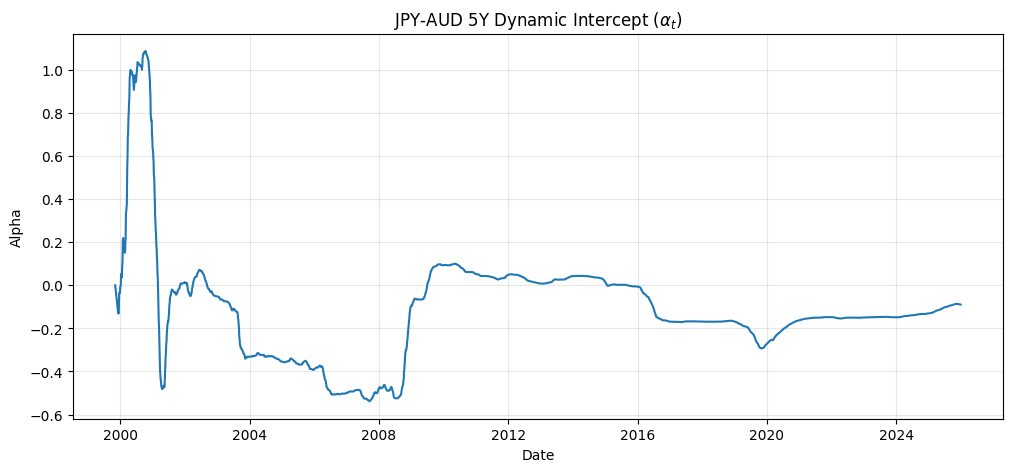

In [33]:
plt.figure(figsize=(12, 5))
plt.plot(spread_df.index, spread_df["alpha_t"])
# plt.title("USD–EUR 5Y Dynamic Intercept ($\\alpha_t$)")
plt.title("JPY-AUD 5Y Dynamic Intercept ($\\alpha_t$)")
plt.xlabel("Date")
plt.ylabel("Alpha")
plt.grid(True, alpha=0.3)
plt.show()

## Kalman Spread

The tradable spread is:

$$
S_t = y_t - \alpha_t - \beta_t x_t
$$

This removes the time-varying directional component associated with EUR rates and isolates the residual relative value dislocation between the two markets.

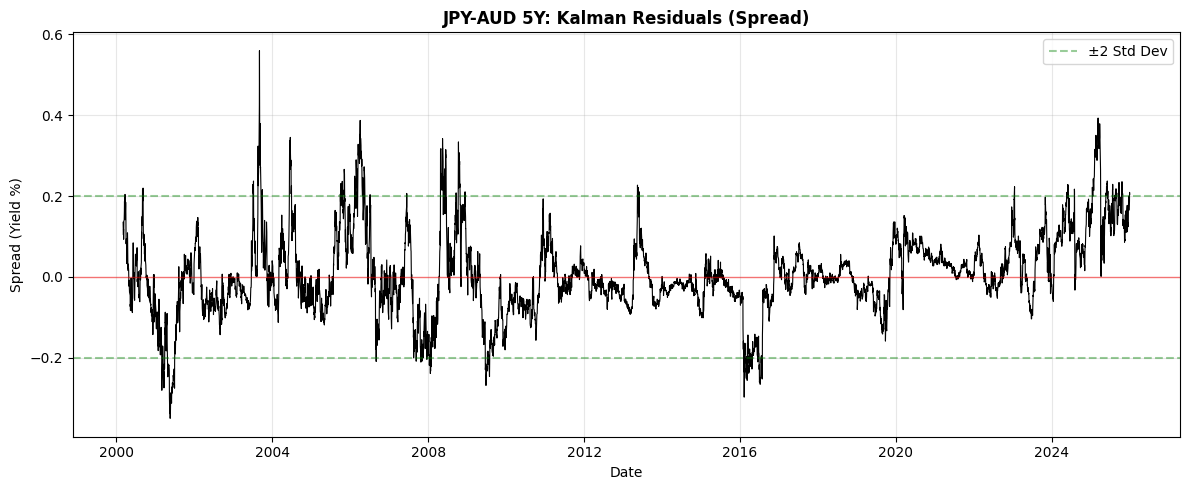

In [34]:
"""
plt.figure(figsize=(12, 5))
plt.plot(spread_df.index, spread_df["spread_t"])
# plt.title("USD–EUR 5Y Kalman Spread")
plt.title("JPY-AUD 5Y Kalman Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(True, alpha=0.3)
plt.show()
"""

plt.figure(figsize=(12, 5))
plt.plot(plot_df.index, plot_df["spread_t"], color='black', linewidth=0.8)

# Add horizontal lines at 0 and ±2 Standard Deviations for scale context
std_spread = plot_df["spread_t"].std()
plt.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.5)
plt.axhline(y=std_spread*2, color='green', linestyle='--', alpha=0.4, label='±2 Std Dev')
plt.axhline(y=-std_spread*2, color='green', linestyle='--', alpha=0.4)

plt.title("JPY-AUD 5Y: Kalman Residuals (Spread)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Spread (Yield %)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Innovation Diagnostics

The Kalman filter also produces the one-step-ahead innovation:

$$
\nu_t = y_t - \hat{y}_{t|t-1}
$$

with variance

$$
Q_t = \mathrm{Var}(\nu_t)
$$

The standardized innovation z-score is:

$$
z_t^{\mathrm{innov}} = \frac{\nu_t}{\sqrt{Q_t}}
$$

This is useful for diagnosing abrupt local dislocations or stress episodes.

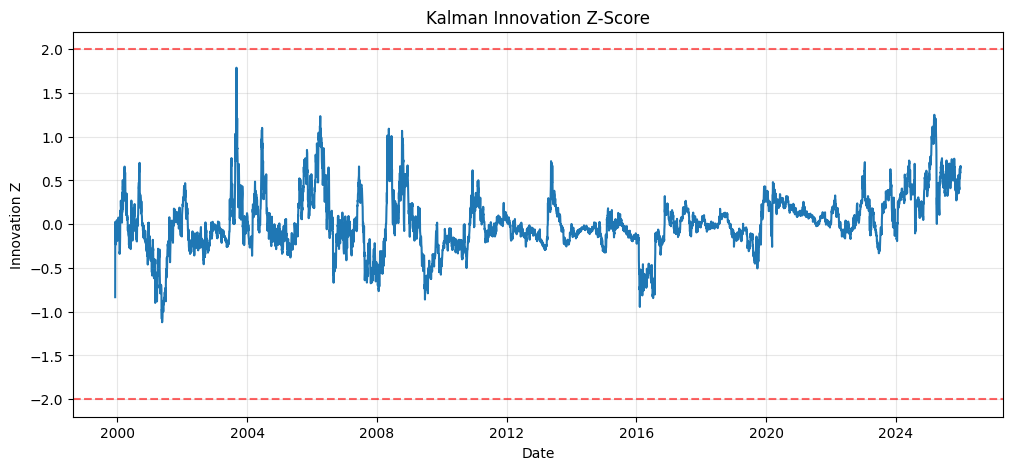

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(spread_df.index, spread_df["innovation_z_t"])
plt.title("Kalman Innovation Z-Score")
plt.xlabel("Date")
plt.ylabel("Innovation Z")
plt.grid(True, alpha=0.3)
plt.axhline(2, linestyle="--", color="red", alpha=0.6)
plt.axhline(-2, linestyle="--", color="red", alpha=0.6)
plt.show()

## Interpretation of Kalman Filter Results

The Kalman filter provides a **time-varying estimate of the equilibrium relationship** between USD and EUR 5Y yields.  
Instead of assuming a fixed hedge ratio (as in static Engle–Granger cointegration), the filter allows the relationship to **evolve gradually over time**, which is consistent with structural changes in global monetary policy, term premia, and funding conditions.

---

## 1. Dynamic Hedge Ratio (βₜ)

The first figure shows the **time-varying hedge ratio βₜ**, which measures the sensitivity of USD 5Y yields to EUR 5Y yields.

Key observations:

- The hedge ratio **varies significantly through time**, roughly between **0.3 and 1.5**.
- This indicates that the **cross-market transmission between US and European rates is not constant**.
- Periods where βₜ rises toward or above 1 typically correspond to **stronger global rate co-movement**, where both markets react similarly to global macro shocks.
- Periods where βₜ falls indicate **weaker linkage**, where regional factors dominate.

From a relative value perspective:

- A **stable βₜ within a regime** suggests that the spread relationship is economically meaningful.
- A **rapid drift in βₜ** may indicate structural shifts such as:
  - monetary policy divergence
  - liquidity fragmentation
  - global risk shocks.

This supports the use of **Kalman filtering as an adaptive measurement tool**, rather than relying on a single static hedge ratio estimated over the full sample.

---

## 2. Dynamic Intercept (αₜ)

The second figure shows the **time-varying intercept αₜ**.

The intercept represents the **baseline structural spread** between the two yield curves after accounting for the hedge ratio.

Interpretation:

- Changes in αₜ reflect **persistent structural differences** between US and EUR yields, such as:
  - inflation expectations
  - term premium differences
  - policy regime shifts
  - currency funding premia.

The gradual evolution of αₜ confirms that the equilibrium spread **moves slowly over time**, reinforcing the need for a **dynamic rather than static equilibrium estimate**.

---

## 3. Kalman Spread

Using the dynamic parameters, the tradable spread is defined as

$$
S_t = y_t - \alpha_t - \beta_t x_t
$$

where

- y_t = USD 5Y yield  
- x_t = EUR 5Y yield  

This spread represents the **residual relative value dislocation** after removing the time-varying equilibrium relationship.

Observations from the spread plot:

- The spread is **centered around zero**, which is **consistent with a mean-reverting structure.**
- Deviations from zero correspond to **temporary relative value dislocations** between the two markets.
- Large spikes typically correspond to **macro stress events or liquidity shocks**.

This spread becomes the **primary object used for mean-reversion modelling in the next step (OU framework).**

---

## 4. Innovation Z-Score Diagnostics and Interpretation

The final figure shows the **standardized Kalman innovations**, defined as

$$
z_t^{innov} = \frac{\nu_t}{\sqrt{Q_t}}
$$

where

- $\nu_t$ = one-step forecast error of the Kalman filter  
- $Q_t$ = variance of the innovation

The innovation represents the **unexpected deviation from the predicted equilibrium relationship** between the two yields.

---

### 1. Centered Around Zero

The innovation series fluctuates around **zero**, which is expected if the Kalman model is correctly capturing the evolving equilibrium relationship between USD and EUR rates.

This suggests that:

- the state-space model is well specified
- most yield movements are explained by the evolving hedge ratio and intercept

Large deviations from zero represent **unexpected shocks** to the relationship.

---

### 2. Volatility Clustering

The innovation series shows **periods of elevated volatility**, particularly during major macro stress events.

These clusters likely correspond to:

- Global Financial Crisis (2008–2009)
- Eurozone sovereign crisis
- COVID market shock
- periods of global liquidity stress

During these episodes, cross-country rate relationships temporarily **deviate from their historical equilibrium**, reflecting fragmentation in global bond markets.

---

### 3. Large Negative and Positive Spikes exceeding 8σ

The extreme spikes in the innovation z-score indicate **sudden cross-market dislocations**.

Economically, these can arise from:

- unexpected monetary policy announcements
- macroeconomic surprises
- liquidity shocks in sovereign bond markets
- funding stress in USD markets

Such events temporarily break the equilibrium relationship captured by the Kalman filter.

---

### 4. Implications for Relative Value Trading

Innovation spikes provide useful information for relative value strategies:

- **Moderate innovations** often represent temporary dislocations that may mean-revert.
- **Very large innovations** may signal structural breaks or regime shifts.

This aligns with the broader research framework of the project:  

Relative value relationships between countries tend to be **stable only within certain macro regimes**, while large shocks can temporarily disrupt these relationships.

---

### Role in the Trading Framework

Within the broader strategy pipeline:

1. **Kalman filter** estimates a dynamic equilibrium relationship.
2. **Spread residuals** measure relative value dislocations.
3. **Innovation z-scores** detect sudden structural deviations from equilibrium.

In practice, innovation spikes can serve as:

- early indicators of **relative value opportunities**, or  
- warnings of **regime shifts where cointegration may temporarily break down**.

---

## Economic Takeaway

The Kalman filter confirms that the USD–EUR 5Y relationship is **not static but evolves gradually through time**.

However:

- The relationship **remains sufficiently stable within certain regimes** to support a mean-reverting spread.
- This aligns with the project’s central hypothesis that **cross-country rate spreads behave as stable relative value relationships only within specific macro regimes.**

The next step is therefore to test whether the Kalman spread exhibits **statistically significant mean reversion**, which will be done using an **Ornstein–Uhlenbeck framework in the next notebook.**